In [1]:
!pip install transformers datasets torch accelerate scikit-learn matplotlib pandas

In [2]:
import os

# Vérifier qu'on est au bon endroit
print(f"📌 Dossier actuel : {os.getcwd()}")

# Si erreur, décommenter et adapter cette ligne :
# os.chdir(r"C:\Users\TonNom\Bureau\AI-CMD-Assistant")

# Vérifier le dataset
files = os.listdir("data/bash_logs/")
print(f"✅ Nombre de fichiers trouvés : {len(files)}")
print(f"📌 Exemples de fichiers :")
for f in files[:3]:
    print(f"   → {f}")

📌 Dossier actuel : C:\Users\ADMIN\Desktop\AI-CMD-Assistant
✅ Nombre de fichiers trouvés : 661
📌 Exemples de fichiers :
   → .ipynb_checkpoints
   → 0067a8e1b6ae52d6a198f6cc86ade5b30cbd5c5d
   → 010db3312e98624bf4ec9723ae737d5e1fa35c7f


📊 Total fichiers        : 660
📏 Min lignes/fichier    : 0
📏 Max lignes/fichier    : 10588
📏 Moyenne               : 309.4
⚠️  Fichiers < 3 lignes  : 44


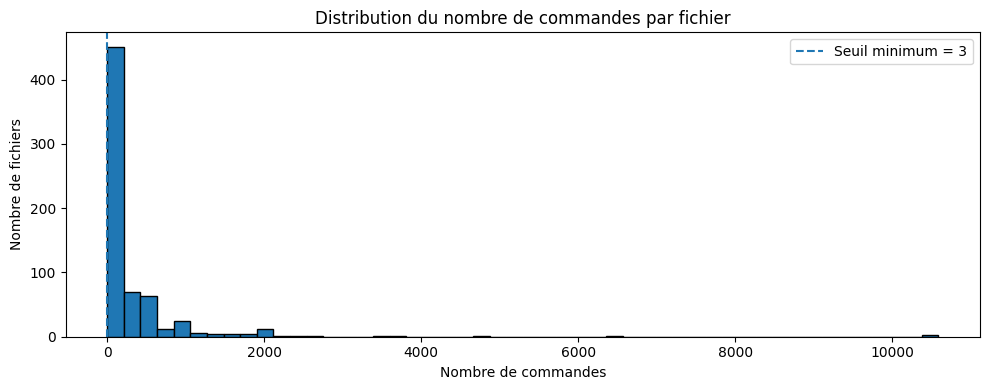

In [5]:
import matplotlib.pyplot as plt
import os

folder = "data/bash_logs/"
sizes = []

for filename in os.listdir(folder):
    filepath = os.path.join(folder, filename)
    
    # ✅ ignorer les dossiers
    if not os.path.isfile(filepath):
        continue
    
    with open(filepath, 'r', errors='ignore') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    sizes.append(len(lines))

# Stats
print("=" * 40)
print(f"📊 Total fichiers        : {len(sizes)}")
print(f"📏 Min lignes/fichier    : {min(sizes)}")
print(f"📏 Max lignes/fichier    : {max(sizes)}")
print(f"📏 Moyenne               : {sum(sizes)/len(sizes):.1f}")
print(f"⚠️  Fichiers < 3 lignes  : {sum(1 for s in sizes if s < 3)}")
print("=" * 40)

# Graphique
plt.figure(figsize=(10, 4))
plt.hist(sizes, bins=50, edgecolor='black')  # ⚠️ pas de couleur selon les règles
plt.title("Distribution du nombre de commandes par fichier")
plt.xlabel("Nombre de commandes")
plt.ylabel("Nombre de fichiers")
plt.axvline(x=3, linestyle='--', label='Seuil minimum = 3')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import re

# Liste des commandes Unix/Linux valides les plus communes
VALID_COMMANDS = {
    # Navigation
    'ls', 'cd', 'pwd', 'mkdir', 'rmdir', 'rm', 'cp', 'mv',
    'find', 'locate', 'tree',
    # Fichiers
    'cat', 'less', 'more', 'head', 'tail', 'touch', 'nano',
    'vim', 'vi', 'gedit', 'echo', 'grep', 'sed', 'awk',
    'cut', 'sort', 'uniq', 'wc', 'diff', 'file', 'stat',
    # Système
    'sudo', 'su', 'chmod', 'chown', 'ps', 'top', 'htop',
    'kill', 'killall', 'df', 'du', 'free', 'uname', 'whoami',
    'id', 'who', 'w', 'uptime', 'history', 'clear', 'exit',
    'reboot', 'shutdown', 'mount', 'umount',
    # Réseau
    'ping', 'curl', 'wget', 'ssh', 'scp', 'ftp', 'netstat',
    'ifconfig', 'ip', 'nmap', 'traceroute', 'dig', 'nslookup',
    # Git
    'git',
    # Package managers
    'apt', 'apt-get', 'yum', 'pip', 'pip3', 'npm', 'yarn',
    'brew', 'snap', 'dpkg',
    # Dev
    'python', 'python3', 'node', 'java', 'javac', 'gcc',
    'make', 'cmake', 'go', 'cargo', 'mvn', 'gradle',
    # Autres utiles
    'tar', 'zip', 'unzip', 'gzip', 'gunzip', 'env',
    'export', 'source', 'alias', 'which', 'man', 'xargs',
    'tee', 'watch', 'cron', 'crontab', 'systemctl', 'service',
    'docker', 'kubectl', 'terraform', 'ansible',
    'view', 'open', 'code', 'sh', 'bash', 'zsh',
}

def is_valid_command(line):
    """Vérifie si la ligne commence par une commande reconnue"""
    first_word = line.strip().split()[0].lower() if line.strip() else ''
    
    # Commande directe reconnue
    if first_word in VALID_COMMANDS:
        return True
    
    # Chemin absolu ou relatif (./script.sh, /usr/bin/...)
    if first_word.startswith('./') or first_word.startswith('/'):
        return True
    
    # Variable d'environnement (VAR=value)
    if re.match(r'^[A-Z_]+=', line.strip()):
        return True
    
    return False

def clean_command(line):
    line = line.strip()
    
    # 1. Ignorer lignes vides ou trop courtes
    if not line or len(line) < 2:
        return None
    
    # 2. Nettoyer liens markdown [texte](url) → texte
    line = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', line)
    
    # 3. Ignorer outputs terminal
    noise_patterns = [
        r'^ubuntu@', r'^root@', r'^user@',
        r'^remote:', r'^Cloning', r'^Counting',
        r'^Compressing', r'^Writing', r'^Unpacking',
        r'^To https://', r'^Branch', r'^On branch',
        r'^Your branch', r'^Changes', r'^Untracked',
        r'^\[master', r'^\[main', r'^fatal:',
        r'^error:', r'^warning:', r'^Password',
        r'^Username', r'^Total', r'^Already',
        r'^done\.', r'^nothing to commit',
    ]
    for p in noise_patterns:
        if re.match(p, line, re.IGNORECASE):
            return None
    
    # 4. Ignorer lignes trop longues
    if len(line) > 300:
        return None
    
    # 5. ✅ NOUVEAU : Vérifier que c'est une commande valide
    if not is_valid_command(line):
        return None
    
    return line

print("✅ Fonction de nettoyage améliorée définie")

✅ Fonction de nettoyage améliorée définie


In [9]:
def load_all_users(folder, min_commands=3):
    all_users = []
    skipped = 0

    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)
        if not os.path.isfile(filepath):
            continue
        try:
            with open(filepath, 'r', errors='ignore') as f:
                lines = f.readlines()

            cmds = [clean_command(l) for l in lines]
            cmds = [c for c in cmds if c is not None]

            if len(cmds) < min_commands:
                skipped += 1
                continue

            all_users.append(cmds)

        except Exception:
            continue

    print("=" * 40)
    print(f"✅ Utilisateurs chargés    : {len(all_users)}")
    print(f"⚠️  Fichiers trop courts   : {skipped}")
    print(f"📝 Total commandes propres : {sum(len(u) for u in all_users)}")
    print("=" * 40)
    return all_users

all_users = load_all_users("data/bash_logs/", min_commands=3)

✅ Utilisateurs chargés    : 589
⚠️  Fichiers trop courts   : 71
📝 Total commandes propres : 153299


In [10]:
from collections import Counter

all_cmds_flat = [cmd for user in all_users for cmd in user]
cmd_names = [cmd.split()[0] for cmd in all_cmds_flat if cmd.split()]
top20 = Counter(cmd_names).most_common(20)

print("🏆 Top 20 commandes les plus fréquentes :\n")
for cmd, count in top20:
    bar = "█" * (count * 30 // top20[0][1])
    print(f"  {cmd:<20} {count:>6}  {bar}")

🏆 Top 20 commandes les plus fréquentes :

  ls                    28976  ██████████████████████████████
  cd                    24239  █████████████████████████
  sudo                  13656  ██████████████
  git                   12529  ████████████
  vim                    9368  █████████
  vi                     5330  █████
  cat                    3834  ███
  make                   3518  ███
  clear                  3158  ███
  rm                     2620  ██
  exit                   2361  ██
  nano                   2283  ██
  python                 1909  █
  pwd                    1428  █
  mv                     1307  █
  echo                   1270  █
  mkdir                  1146  █
  man                    1118  █
  less                   1118  █
  ps                     1083  █


In [18]:
import json
import random

WINDOW_SIZE = 3 #si on veut trainer le modèle sur une seule cmd pas plus on change WINDOW_SIZE = 1
SEP = " <CMD> "

def create_sequences(all_users, window_size=3):
    sequences = []
    skipped = 0
    for user_cmds in all_users:
        if len(user_cmds) <= window_size:
            skipped += 1
            continue
        for i in range(len(user_cmds) - window_size):
            window = user_cmds[i : i + window_size + 1]
            text = SEP.join(window)
            sequences.append(text)
    print(f"✅ Séquences créées : {len(sequences)}")
    print(f"⚠️  Users skippés   : {skipped}")
    return sequences

sequences_raw = create_sequences(all_users, WINDOW_SIZE)

# Dédupliquer
sequences_unique = list(set(sequences_raw))
print(f"✅ Après dédup : {len(sequences_unique)}")

# Shuffle
random.seed(42)
random.shuffle(sequences_unique)
print(f"✅ Shuffle fait")

# Sauvegarder
json.dump(sequences_unique, open("data/preprocessed/sequences_dedup.json", "w"))
print(f"✅ Sauvegardé → sequences_dedup.json")

✅ Séquences créées : 151532
⚠️  Users skippés   : 17
✅ Après dédup : 130606
✅ Shuffle fait
✅ Sauvegardé → sequences_dedup.json


In [ ]:
#les etapes de training dans google colab

# CELLULE 1 — GPU Check + Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import torch
print("GPU dispo :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

# CELLULE 2 — Installer libs
!pip install transformers datasets -q

# CELLULE 3 — Charger les données depuis Drive
import json

sequences = json.load(open("/content/drive/MyDrive/AI-CMD-Assistant/sequences_dedup.json"))
print(f"✅ {len(sequences)} séquences chargées")


#cellule 4
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({"sep_token": "<CMD>"})
tokenizer.pad_token = tokenizer.eos_token
print(f"✅ Vocab : {len(tokenizer)}")

#cellule 5
from torch.utils.data import Dataset

class BashDataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=64):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        tokens = self.tokenizer(
            self.sequences[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        input_ids = tokens["input_ids"].squeeze()
        return {"input_ids": input_ids, "labels": input_ids}

split = int(0.8 * len(sequences))
train_data = BashDataset(sequences[:split], tokenizer)
val_data   = BashDataset(sequences[split:], tokenizer)
print(f"✅ Train : {len(train_data)} | Val : {len(val_data)}")

# CELLULE 6 — Training (avec GPU = ~20-30 min !)
from transformers import GPT2LMHeadModel, Trainer, TrainingArguments

model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/AI-CMD-Assistant/gpt2-bash-final3",
    num_train_epochs=3,
    per_device_train_batch_size=32,   # batch plus grand grâce au GPU
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    fp16=True,                        # activé car GPU Colab
    report_to="none",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
)

trainer.train()
print("✅ Training terminé !")

# CELLULE 7 — Sauvegarder le modèle sur Drive
model.save_pretrained("/content/drive/MyDrive/AI-CMD-Assistant/gpt2-bash-final3")
tokenizer.save_pretrained("/content/drive/MyDrive/AI-CMD-Assistant/gpt2-bash-final3")
print("✅ Modèle sauvegardé sur Drive !")







/*✅ Val Loss légèrement < Train Loss  → normal, pas d'overfitting
✅ Les deux diminuent ensemble       → modèle apprend bien
⚠️  Val Loss remonte à Epoch 3       → overfitting, arrêter
❌  Val Loss >> Train Loss           → gros overfitting

In [2]:
#évaluation et pédiction

from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

model_path = "models/gpt2-bash-final3"
tokenizer = GPT2Tokenizer.from_pretrained(model_path)
model = GPT2LMHeadModel.from_pretrained(model_path)
model.eval()
print("✅ Modèle chargé !")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Modèle chargé !


In [6]:
def predict_next_command(previous_commands, top_k=1):#si on veut prédire juste  une seule valeur 
    SEP = "<CMD>"
    input_text = (" " + SEP + " ").join(previous_commands) + " " + SEP + " "
    inputs = tokenizer(input_text, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_new_tokens=15,
            num_return_sequences=top_k,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    
    predictions = []
    for output in outputs:
        decoded = tokenizer.decode(output, skip_special_tokens=False)
        # Prendre tout ce qui est après le dernier <CMD>
        parts = decoded.split("<CMD>")
        if len(parts) > 1:
            next_cmd = parts[-1]
            # Nettoyer endoftext et espaces
            next_cmd = next_cmd.split("<|endoftext|>")[0].strip()
            if next_cmd:
                predictions.append(next_cmd)
    
    predictions = list(dict.fromkeys(predictions))  # dédoublonner
    return predictions

# Tests
print("Test 1:", predict_next_command(["ls", "cd src/", "git status"]))
print("Test 2:", predict_next_command(["git add .", "git commit -m 'fix'"]))
print("Test 3:", predict_next_command(["sudo apt update"]))
print("Test 4:", predict_next_command(["git add ."]))
print("Test 4:", predict_next_command(["git commit -m 'fix'"]))
print("test6: ",predict_next_command(["git add", "git commit", "git push"]))  
print("test7: ",predict_next_command(["git pull", "git merge","git push"])) 




Test 1: ['git status']
Test 2: ['git push origin master']
Test 3: ['sudo apt install git']
Test 4: ["git commit -m 'adding the proper image-upload function to image"]
Test 4: ['git push -u origin master']
test6:  ['git status']
test7:  ['git pull']


In [ ]:
#les etapes de training dans google colab

# CELLULE 1 — GPU Check + Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import torch
print("GPU dispo :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

# CELLULE 2 — Installer libs
!pip install transformers datasets -q

# CELLULE 3 — Charger les données depuis Drive
import json

sequences = json.load(open("/content/drive/MyDrive/AI-CMD-Assistant/sequences_dedup.json"))
print(f"✅ {len(sequences)} séquences chargées")


#cellule 4
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({"sep_token": "<CMD>"})
tokenizer.pad_token = tokenizer.eos_token
print(f"✅ Vocab : {len(tokenizer)}")

#cellule 5
from torch.utils.data import Dataset

class BashDataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=64):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        tokens = self.tokenizer(
            self.sequences[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        input_ids = tokens["input_ids"].squeeze()
        return {"input_ids": input_ids, "labels": input_ids}

split = int(0.8 * len(sequences))
train_data = BashDataset(sequences[:split], tokenizer)
val_data   = BashDataset(sequences[split:], tokenizer)
print(f"✅ Train : {len(train_data)} | Val : {len(val_data)}")

#cellule6
import math
from transformers import GPT2LMHeadModel, Trainer, TrainingArguments

model = GPT2LMHeadModel.from_pretrained(
    "/content/drive/MyDrive/AI-CMD-Assistant/gpt2-bash-final3/checkpoint-9798"
)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/AI-CMD-Assistant/eval",
    per_device_eval_batch_size=32,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=val_data,  # déjà créé dans cellule 5
)

results = trainer.evaluate()
perplexity = math.exp(results["eval_loss"])
print(f"✅ Val Loss   : {results['eval_loss']:.4f}")
print(f"✅ Perplexity : {perplexity:.2f}")

In [ ]:
#version d'évaluation rapide c'est dans google colab bien sur après l'execution des autres cellule
import math
import torch
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained(
    "/content/drive/MyDrive/AI-CMD-Assistant/gpt2-bash-final3/checkpoint-9798"
)
model.eval()
total_loss = 0
count = 0

for i in range(min(500, len(val_data))):
    input_ids = val_data[i]["input_ids"].unsqueeze(0)
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        total_loss += outputs.loss.item()
        count += 1

perplexity = math.exp(total_loss / count)
print(f"✅ Val Loss   : {total_loss/count:.4f}")
print(f"✅ Perplexity : {perplexity:.2f}")